In [18]:
import os
import pickle
import pathlib

import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
from matplotlib import gridspec
import seaborn as sns
import pandas as pd
import pingouin as pg

import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u
import TwoPUtils as tpu

ko_mice = stx.ymaze_sess_deets.ko_mice
ctrl_mice = stx.ymaze_sess_deets.ctrl_mice
sparse_mice = stx.ymaze_sess_deets.sparse_mice


plt.rcParams['pdf.fonttype']=42
%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
sess = u.load_vr_day(ko_mice[0],5, pkldir = '/mnt/BigDisk/YMaze_VR_Pkls')
# sess = u.load_single_day(sparse_mice[0],5)

{'date': '03_10_2020', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': 3, 'novel_arm': -1, 'ravel_ind': 6}


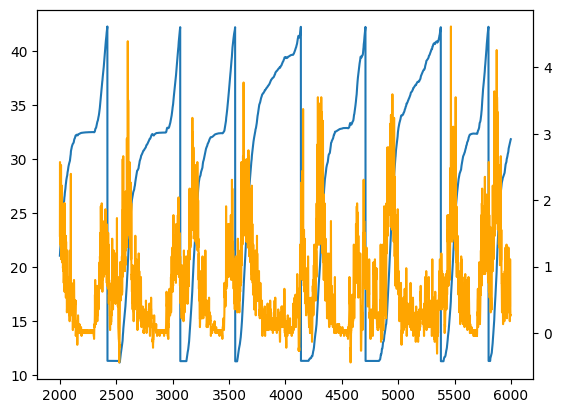

In [20]:
fig, ax = plt.subplots()
# mask = sess.vr_data['t']==-1000
# sess.vr_data.loc[mask]=np.nan
ax.plot(sess.vr_data['t'].iloc[2000:6000])
ax2 = ax.twinx()
ax2.plot(sess.vr_data['dz'].iloc[2000:6000]*10, color='orange')
# ax.plot()
    # ax.scatter(np.diff(sess.vr_data['t']), sess.vr_data['dz'].iloc[1:])

In [21]:
ax.plot()

[]

In [22]:
cov = sp.stats.variation(sess.trial_matrices['speed'][sess.trial_info['LR']==sess.novel_arm, :], axis=0, nan_policy='omit')

In [23]:
print(sess.trial_matrices['speed'][sess.trial_info['LR']==sess.novel_arm, :])

[[48.44829762 58.96922982 65.13895761 ... 51.48602101 41.96866521
  39.50336613]
 [47.125342   50.28849126 53.12306242 ... 49.84080724 46.98017841
  37.67522938]
 [55.47953772 62.68010196 69.96653807 ... 41.21526293 28.35261655
  23.11511208]
 ...
 [41.65698413 53.48944287 71.01161905 ... 44.85555616 45.90334063
  44.38888889]
 [47.86820786 54.44208863 68.83779258 ... 41.48216566 42.3622811
  42.71509434]
 [33.69957376 46.17926249 48.5112705  ... 45.90852232 48.11466911
  43.38136364]]


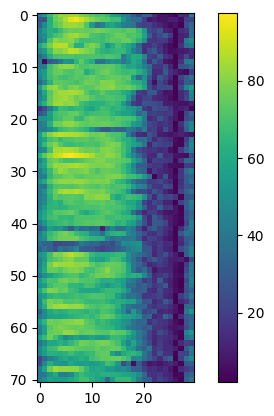

In [24]:
fig, ax = plt.subplots()
h = ax.imshow(sess.trial_matrices['speed'][sess.trial_info['LR']!=sess.novel_arm, :])
plt.colorbar(h)


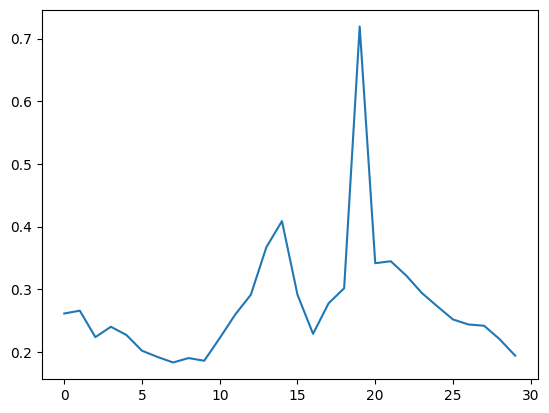

In [25]:
fig, ax = plt.subplots()
ax.plot(cov)

In [14]:
arr = []
for start,stop in zip(sess.trial_start_inds, sess.teleport_inds):
    arr.append([sess.vr_data['time'].iloc[start], sess.vr_data['time'].iloc[stop]])

In [15]:
arr = np.array(arr)
trial_dur = arr[:,1]-arr[:,0]

In [16]:
np.nanmean(sess.trial_matrices['speed'], axis=-1)

array([30.79222655, 42.67597359, 43.95815016, 42.18341347, 47.8627045 ,
       44.70734634, 40.94235415, 45.81801968, 42.27652864, 38.97599484,
       35.70398632, 43.24164229, 42.45657996, 45.47047109, 40.90232533,
       35.82953211, 43.16413324, 42.02520907, 49.43915673, 46.84860443,
       32.4914447 , 36.06454778, 40.25201062, 45.42716491, 36.94312023,
       37.48638764, 40.67305753, 36.17474655, 47.62803206, 47.89081088,
       36.73277553, 41.7404089 , 42.75768373, 45.40818943, 52.56880943,
       42.99352148, 41.06275966, 44.28363954, 46.792711  , 49.99099109,
       35.19791694, 36.9069632 , 41.04548987, 50.70476034, 47.74292669,
       41.63723876, 41.05725819, 56.16433037, 49.40980079, 47.34631266,
       43.51329516, 52.28101089, 53.61916401, 28.76850059, 37.56656143,
       49.30543889, 53.28498178, 43.91747484, 51.65647739, 48.03116446,
       36.820186  , 44.309863  , 51.85668548, 37.77090827, 41.70223585,
       39.27457949, 48.4680276 , 52.82298674, 51.68189857, 48.95

In [18]:
for i in range(trial_dur.shape[0]):
    print(trial_dur[i], 300/np.nanmean(sess.trial_matrices['speed'][i], axis=-1))

13.316010000000006 9.742718652221509
12.065759999999997 7.029716601233743
13.315600000000003 6.824672987812202
12.256650000000008 7.111800001728955
11.139700000000005 6.267928298602143
12.625399999999999 6.71030657229304
14.747500000000002 7.3273754341682285
12.014999999999986 6.547642217435142
9.943999999999988 7.096136075159906
11.881299999999982 7.697045354793911
13.18379999999999 8.402423117317097
11.890199999999993 6.937756849416992
13.173100000000005 7.066042537643491
11.197000000000003 6.597688407310821
11.637000000000029 7.334546326169635
12.750299999999982 8.37298123561148
11.743899999999996 6.950214853106634
13.396500000000003 7.138572457705394
10.942100000000039 6.0680646648457435
9.527499999999975 6.403605905738174
12.872099999999989 9.233199777208853
13.490000000000009 8.318418459456943
12.243899999999996 7.453043845780553
8.690399999999954 6.603978051023861
10.136799999999994 8.120591821481776
12.21210000000002 8.002905024802116
10.485199999999963 7.37589004249594
11.6981